In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
data_path = '/content/drive/MyDrive/dane_zad_1/titanic.csv'

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

titanic_df = pd.read_csv(data_path, index_col='PassengerId')


In [55]:

def get_percentage_missing(df, axis):

  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]


In [56]:

brakujace_dane = get_percentage_missing(titanic_df, axis=0)
brakujace_dane


,0
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


Sprawdzam w których kolumnach są brakujące wartości

In [57]:
puste_wiersze_pr = get_percentage_missing(titanic_df, axis=1)
puste_cale_wiersze = puste_wiersze_pr[puste_wiersze_pr == 100].index
titanic_df.loc[puste_cale_wiersze]


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,


Sprawdzam czy nie występują puste wiersze.
Wniosek: Nie występują

In [58]:
def get_column_distribution(df, column):
  return df[column].value_counts(normalize=True)

In [59]:
get_column_distribution(titanic_df, "Age")

,proportion
Age,
24.00,0.042017
22.00,0.037815
18.00,0.036415
28.00,0.035014
30.00,0.035014
...,...
24.50,0.001401
0.67,0.001401
0.42,0.001401


Rozklad wartosci przed uzupelnieniem

In [60]:
prawdopodobienstwo_wiek = get_column_distribution(titanic_df, 'Age')
wiek_wartosci = prawdopodobienstwo_wiek.index
wiek_szanse = prawdopodobienstwo_wiek.values
ilosc_brakuajcych_wiekow = titanic_df.Age.isna()
titanic_df.loc[ilosc_brakuajcych_wiekow, 'Age'] = np.random.choice(wiek_wartosci, size=ilosc_brakuajcych_wiekow.sum(), p=wiek_szanse)
titanic_df.Age.isna().sum()


np.int64(0)

Zastąpiłem puste wartości w wieku losowymi wartościami na podstawie wcześniejszego rozkładu.

In [61]:
get_column_distribution(titanic_df, "Age")

,proportion
Age,
24.00,0.040404
19.00,0.039282
22.00,0.038159
28.00,0.035915
18.00,0.035915
...,...
0.92,0.001122
23.50,0.001122
24.50,0.001122


Rozklad wartosci po uzupelnieniu

In [62]:
srednia_cena_biletu_dla_klasy=titanic_df.groupby('Pclass')['Fare'].mean()
srednia_cena_biletu_dla_klasy

,Fare
Pclass,
1,86.771177
2,20.489127
3,13.886074


Brakujące dane o cenie biletu uzupełnimy średnią ceną biletu w zależności od klasy.

In [63]:
titanic_df["Fare"]=titanic_df["Fare"].fillna(titanic_df['Pclass'].map(srednia_cena_biletu_dla_klasy))
titanic_df["Fare"].isna().sum()

np.int64(0)

In [64]:
titanic_df["Embarked"].isna().sum()

np.int64(2)

In [65]:
titanic_df["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [66]:
titanic_df["Embarked"]=titanic_df["Embarked"].fillna('S')

Tylko dwa razy występuje NaN w kolumnie Embarked więc uzupełniam ją dominującym znakiem.

In [67]:
brakujace_dane = get_percentage_missing(titanic_df, axis=0)
brakujace_dane


,0
Cabin,77.1


Wszystkie brakujące dane zostały uzupełnione

In [68]:
wielkość_rodziny = lambda x: x['SibSp'] + x['Parch']+1
titanic_df['Family_size']=titanic_df.apply(wielkość_rodziny, axis=1)
titanic_df['IsChild']=0
titanic_df.loc[titanic_df.Age<18,'IsChild']=1


Dodaję dwie nowe kolumny:
1.Family Size-> Wielkość rodziny łącznie z pasażerem.
2.IsChild->czy dana osoba jest dzieckiem.

In [69]:
titanic_df["Ticket"].value_counts()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


Sprawdzam możliwość ukrytych zależności w numerze biletu.


In [70]:
titanic_df[titanic_df['Ticket'] == "347082"]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_size,IsChild
PassengerId,,,,,,,,,,,,,
14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.275000,NaN,S,7,0
120,0,3,"Andersson, Miss. Ellis Anna Maria",female,2.0,4,2,347082,31.275000,NaN,S,7,1
542,0,3,"Andersson, Miss. Ingeborg Constanzia",female,9.0,4,2,347082,31.275000,NaN,S,7,1
543,0,3,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.275000,NaN,S,7,1
611,0,3,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",female,39.0,1,5,347082,31.275000,NaN,S,7,0
814,0,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,347082,13.886074,NaN,S,7,1
851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.275000,NaN,S,7,1


Jak widać numer biletu był przydzielony dla rodzin. Mamy już kolumny które dają nam tą informację dlatego uważam iż ta kolumna nie jest potrzebna w kontekście zadania.

In [71]:
titanic_df.drop(['Name', 'Ticket','Cabin'], axis=1, inplace=True)

Usuwam trzy kolumny ponieważ:
Name->Jedyne co mogłobybyć ważne w kontekście zadania w tej kolumnie to przydomek który może świadczyć o statucie społecznym.Zakodowanie tej kolumny zwiększyłoby tylko wymiarowość danych a statut społeczny można wyciągnąć z Pclass.
Ticket->Wyjaśniłem w komentarzu powyżej.
Cabin->Jest za dużo brakujących danych Kabina w dużym stopniu wpłynęła na przeżywalność lecz przy prawie 80% brakujących danych nie jestem wstanie adekwatnie jej uzupełnić.

In [72]:
titanic_df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
Family_size,0
IsChild,0


Nie ma już brakujących danych.

In [73]:

titanic_df.Sex.unique()

array(['male', 'female'], dtype=object)

In [74]:
titanic_df['Sex'] = titanic_df.Sex.map({
    'male': 1, 'female': 0
})
titanic_df['Sex'].value_counts()

,count
Sex,
1,577
0,314


Binary encoding dla płci.

In [75]:
titanic_df = pd.get_dummies(titanic_df, columns=["Embarked"], dtype=int)
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Family_size,IsChild,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,1,22.0,1,0,7.2500,2,0,0,0,1
2,1,1,0,38.0,1,0,71.2833,2,0,1,0,0
3,1,3,0,26.0,0,0,7.9250,1,0,0,0,1
4,1,1,0,35.0,1,0,53.1000,2,0,0,0,1
5,0,3,1,35.0,0,0,8.0500,1,0,0,0,1


One Hot Encoding dla Embarked.
Dane Kategorialne zamieniłem już na liczbowe.

In [76]:
titanic_df.dtypes

,0
Survived,int64
Pclass,int64
Sex,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Family_size,int64
IsChild,int64
Embarked_C,int64


Age nie powinno być floatem.

In [77]:
titanic_df['Age'] = titanic_df['Age'].astype(int)

funckją astype() zmieniam typ danych

In [78]:
titanic_df.dtypes

,0
Survived,int64
Pclass,int64
Sex,int64
Age,int64
SibSp,int64
Parch,int64
Fare,float64
Family_size,int64
IsChild,int64
Embarked_C,int64


Sprawdzę teraz czy występują jakieś outliery w kolumnach liczbowych. Wnioski wyciągne z boxplota.

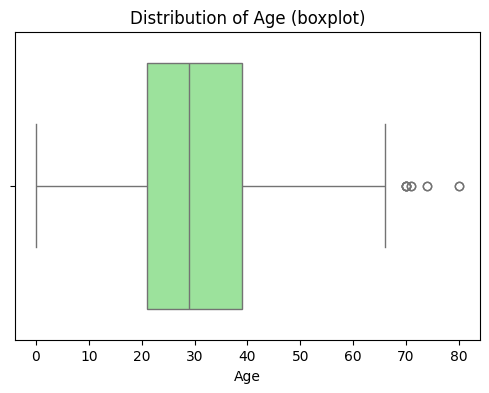

In [79]:

def boxplot(df, column_name):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column_name].dropna(), color='lightgreen') # as you can see, you can use sns and plt at the same time
    plt.title(f'Distribution of {column_name} (boxplot)')
    plt.xlabel(column_name)

    plt.show()
boxplot(titanic_df, "Age")

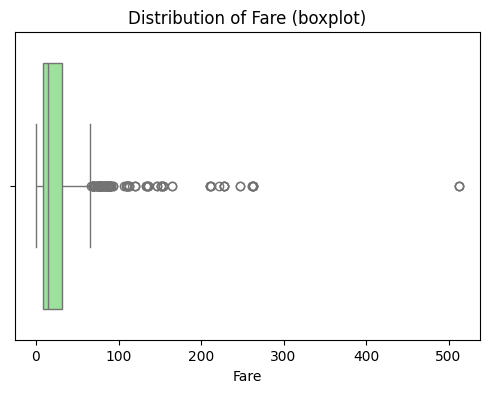

In [80]:
boxplot(titanic_df, "Fare")

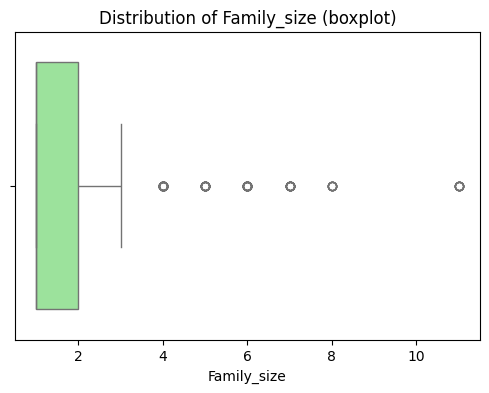

In [81]:
boxplot(titanic_df, "Family_size")

Występują outliery szczególnie w Fare lecz wszystkie mają sens ponieważ oddają wartości które nie są w żaden sposób niemożliwe


 Sprawdzam czy są jakieś rzadko występujące odstające wartości w innych kolumnach


In [82]:
titanic_df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [83]:
titanic_df["Embarked_C"].value_counts()

,count
Embarked_C,
0,723
1,168


In [84]:
titanic_df["Embarked_S"].value_counts()

,count
Embarked_S,
1,646
0,245


In [85]:
titanic_df["Embarked_Q"].value_counts()

,count
Embarked_Q,
0,814
1,77


Embarked S i C przeważają.

In [86]:
def plot_correlation_matrix(df):

    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()


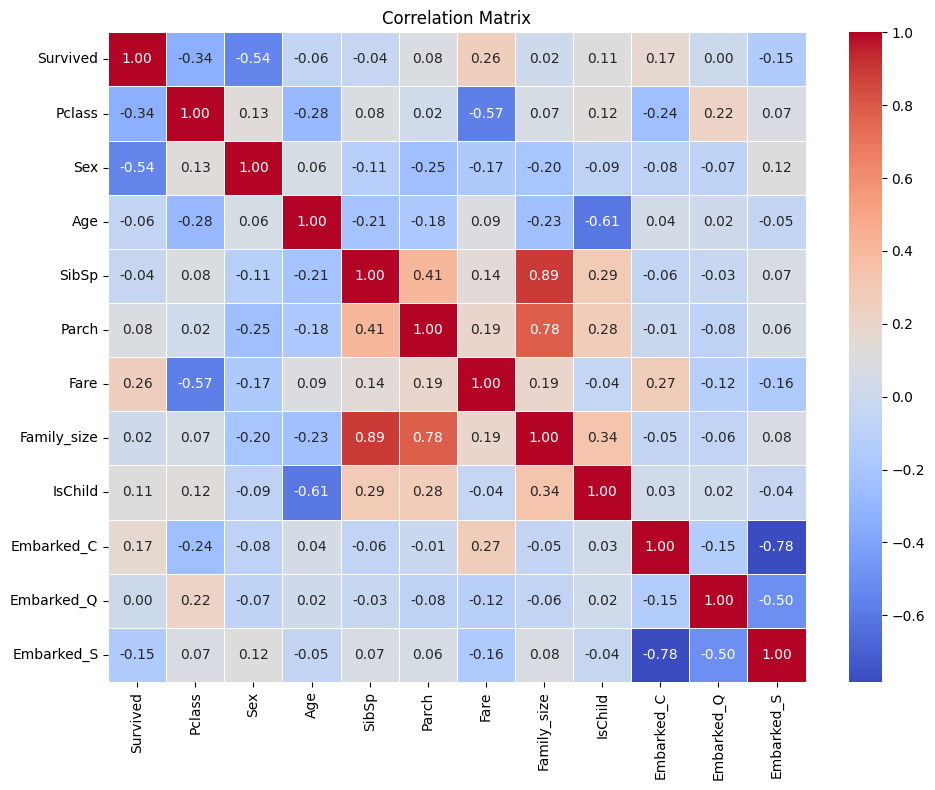

In [87]:
plot_correlation_matrix(titanic_df)

Sprawdzam korelację między poszczególnymi cechami.
Widać że:
Płeć mocno wpłynęła na przeżywalność -0.54 świadczy o większej ilości zgonów mężczyzn niż kobiet. Podobnie widać że dzieci 0.11 częsciej przeżywały.
Pclass też ma mocną korelacją skąd możemy wyciągnąć wnioski iż bogatsi częsciej przeżywali


In [88]:
def plot_numeric_histogram(df, column_name):
    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()


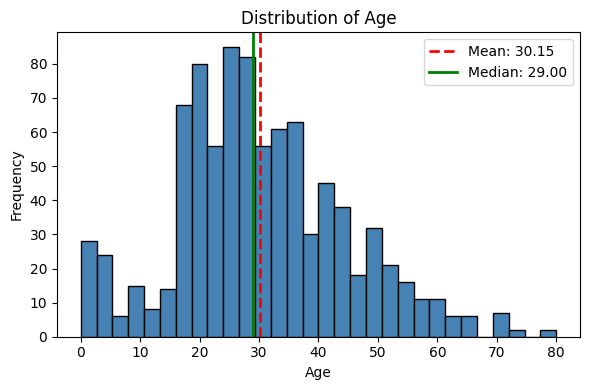

In [89]:
plot_numeric_histogram(titanic_df, "Age")

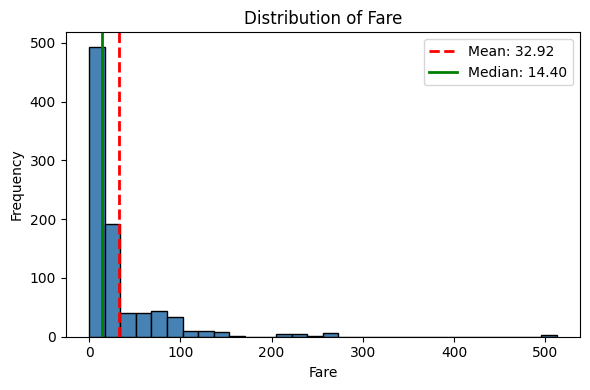

In [90]:
plot_numeric_histogram(titanic_df, "Fare")